# New Section

In [ ]:

# AC CONDITION PREDICTION - TRAINING CELL

import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
# --- LOAD DATA ---

file_path = Path("/content/thingspeak_full_data (1).csv")
df = pd.read_csv(file_path)
# if "field1" in df.columns:
    # df = df.rename(columns={"field1": "Temperature", "field2": "Humidity", "field3": "Vibration"})
df = df[["Date", "Temperature", "Humidity", "Vibration"]]
df["Date"] = pd.to_datetime(df["Date"], format="mixed")
df = df.sort_values("Date").ffill()
df = df[df["Vibration"] < 50]
# --- CREATE STATUS USING PROJECT THRESHOLDS ---

def parameter_status(value, normal_limit, warning_limit):
    if value > warning_limit: return 2
    elif value > normal_limit: return 1
    else: return 0
def generate_status(row):
    temp_l = parameter_status(row["Temperature"], 36, 42)
    hum_l = parameter_status(row["Humidity"], 95, 98)
    vib_l = parameter_status(row["Vibration"], 2, 10)
    highest = max(temp_l, hum_l, vib_l)
    if highest == 2: return "CRITICAL"
    elif highest == 1: return "WARNING"
    else: return "NORMAL"
df["Status"] = df.apply(generate_status, axis=1)
# --- FEATURE ENGINEERING ---

df["temp_prev1"] = df["Temperature"].shift(1)
df["temp_prev2"] = df["Temperature"].shift(2)
df["hum_prev1"] = df["Humidity"].shift(1)
df["vib_prev1"] = df["Vibration"].shift(1)
df["vib_prev2"] = df["Vibration"].shift(2)
df["temp_trend"] = df["Temperature"] - df["temp_prev1"]
df["vib_trend"] = df["Vibration"] - df["vib_prev1"]
df["temp_roll_mean"] = df["Temperature"].rolling(3).mean()
df["vib_roll_mean"] = df["Vibration"].rolling(3).mean()
df = df.dropna()
# --- FEATURES & TARGET ---

features = ["Temperature", "Humidity", "Vibration", "temp_prev1", "temp_prev2", "hum_prev1", "vib_prev1", "vib_prev2", "temp_trend", "vib_trend", "temp_roll_mean", "vib_roll_mean"]
X = df[features]
le = LabelEncoder()
y = le.fit_transform(df["Status"])
# --- MODEL TRAINING ---

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = RandomForestClassifier(n_estimators=100, max_depth=7, min_samples_leaf=5, random_state=42, class_weight="balanced")
model.fit(X_train_scaled, y_train)
# --- EVALUATION & SAVE ---

y_pred = model.predict(X_test_scaled)
print(f"\nTraining Complete. Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
joblib.dump(model, "ac_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")
print("Model Saved Successfully!")


Training Complete. Accuracy: 0.9988

Classification Report:
               precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00      1558
     WARNING       1.00      0.95      0.98        42

    accuracy                           1.00      1600
   macro avg       1.00      0.98      0.99      1600
weighted avg       1.00      1.00      1.00      1600

Model Saved Successfully!


In [ ]:
import pandas as pd
import joblib
# Load model
model = joblib.load("ac_model.pkl")
scaler = joblib.load("scaler.pkl")
le = joblib.load("label_encoder.pkl")
# Load dataset only for previous readings
df = pd.read_csv("/content/thingspeak_full_data testing.csv")

# Last two readings
p1 = df.iloc[-1]
p2 = df.iloc[-2]
def predict_status(temp, hum, vib):
    features = pd.DataFrame([[
        temp, hum, vib,
        p1.Temperature, p2.Temperature,
        p1.Humidity,
        p1.Vibration, p2.Vibration,
        temp-p1.Temperature, vib-p1.Vibration,
        (temp+p1.Temperature+p2.Temperature)/3,
        (vib+p1.Vibration+p2.Vibration)/3
    ]], columns=[
        "Temperature","Humidity","Vibration",
        "temp_prev1","temp_prev2","hum_prev1",
        "vib_prev1","vib_prev2","temp_trend",
        "vib_trend","temp_roll_mean","vib_roll_mean"
    ])
    pred = model.predict(scaler.transform(features))
    return le.inverse_transform(pred)[0]
# Enter only these values
temp, hum, vib = 38, 85, 4
print("Prediction :", predict_status(temp, hum, vib))

Prediction : WARNING


In [ ]:
import pandas as pd
df = pd.read_csv("/content/thingspeak_full_data testing.csv")

print("Automation Test\n")
for i in range(4025,4035):
    p1, p2, cur = df.iloc[i-1], df.iloc[i-2], df.iloc[i]
    features = pd.DataFrame([[
        cur.Temperature, cur.Humidity, cur.Vibration,
        p1.Temperature, p2.Temperature,
        p1.Humidity,
        p1.Vibration, p2.Vibration,
        cur.Temperature-p1.Temperature, cur.Vibration-p1.Vibration,
        (cur.Temperature+p1.Temperature+p2.Temperature)/3,
        (cur.Vibration+p1.Vibration+p2.Vibration)/3
    ]], columns=[
        "Temperature","Humidity","Vibration",
        "temp_prev1","temp_prev2","hum_prev1",
        "vib_prev1","vib_prev2","temp_trend",
        "vib_trend","temp_roll_mean","vib_roll_mean"
    ])
    pred = model.predict(scaler.transform(features))
    status = le.inverse_transform(pred)[0]
    print(f"Reading {i-1}: T={cur.Temperature}, H={cur.Humidity}, V={cur.Vibration} --> {status}")

Automation Test

Reading 4024: T=33.0, H=95.0, V=0.1 --> NORMAL
Reading 4025: T=33.1, H=95.0, V=0.3 --> NORMAL
Reading 4026: T=33.1, H=95.0, V=1.15 --> NORMAL
Reading 4027: T=33.9, H=95.0, V=1.6 --> NORMAL
Reading 4028: T=33.3, H=95.0, V=0.05 --> NORMAL
Reading 4029: T=33.2, H=95.0, V=0.2 --> NORMAL
Reading 4030: T=33.1, H=95.0, V=0.05 --> NORMAL
Reading 4031: T=33.1, H=95.0, V=0.2 --> NORMAL
Reading 4032: T=33.1, H=95.0, V=0.15 --> NORMAL
Reading 4033: T=33.1, H=95.0, V=0.1 --> NORMAL


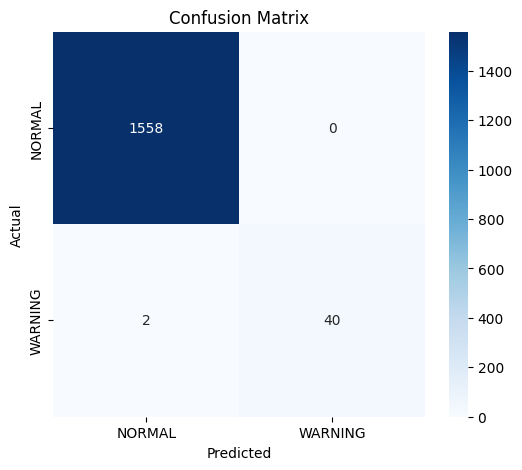

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict on test data
y_pred = model.predict(X_test_scaled)

# Convert labels back to text
y_true = le.inverse_transform(y_test)
y_pred = le.inverse_transform(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=le.classes_)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
!ls -l /content/

total 308
drwx------ 5 root root   4096 Jul 10 10:35  drive
drwxr-xr-x 1 root root   4096 Jun  4 13:32  sample_data
-rw-r--r-- 1 root root 304673 Jul 10 10:38 'thingspeak_full_data (1).csv'
